# Project: Credit Card Churn Prediction

Credit card churn refers to the situation where a customer discontinues their credit card service with a financial institution.

**The Problem:**
Credit card companies need to identify which customers are likely to churn so that they can take proactive measures to retain them. Retaining high-value customers can lead to increased lifetime value (LTV) and a more stable customer base.

**The Objective:**
The primary goal is to predict customer churn using data-driven approaches. This includes analyzing customer behavior, transaction history, demographics, and engagement metrics to determine the likelihood of churn. Timely identification of at-risk customers allows the company to implement targeted retention strategies, such as offering tailored incentives, improving services, or addressing customer complaints.

**Business Use Case** using **ML:**
Machine Learning plays a critical role in credit card churn prediction by analyzing large volumes of customer data to identify patterns and predict the likelihood of churn. This allows businesses to proactively retain high-risk customers through targeted interventions and optimize retention strategies.

# Project Appendix
- Data Processing (Descriptive Statistics, Data Cleaning, One-hot Encoding)
- Exploratory Data Analysis
- Feature Selection
- Data Preparation
- Model Training and Data Splitting
- Machine Learning Modeling
- Evaluation Metrics
- Recommendation 

In [614]:
!pip install watermark


In [615]:
# System libraries
import re
import os
import unicodedata
import itertools

# Library for file manipulation
import pandas as pd
import numpy as np
import pandas

# Data visualization
import plotly
import seaborn as sns
import matplotlib.pylab as pl
import matplotlib as m
import matplotlib as mpl
import matplotlib.pyplot as plt
import plotly.express as px
from matplotlib import pyplot as plt
from IPython.display import SVG

# Configuration for graphs width and layout of graphs
sns.set_theme(style='whitegrid')
palette='viridis'

# Warnings remove warnings
import warnings
warnings.filterwarnings("ignore")

# Python version
from platform import python_version
print('Python version in this Jupyter Notebook:', python_version())

# Load library versions
import watermark

# Library versions
%reload_ext watermark
%watermark -a "Library versions" --iversions

Python version in this Jupyter Notebook: 3.12.4
Author: Library versions

IPython   : 8.25.0
platform  : 1.0.8
lightgbm  : 4.5.0
json      : 2.0.9
matplotlib: 3.8.4
pandas    : 2.2.2
seaborn   : 0.13.2
re        : 2.2.1
sklearn   : 1.4.2
numpy     : 1.26.4
plotly    : 5.22.0
tqdm      : 4.66.4
xgboost   : 2.1.3
watermark : 2.5.0



## Data Processing
Here is a description of the dataset:
- **CLIENTNUM:** Unique identification number for each customer.
- **Attrition_Flag:** Status  of the customer's churn/active. **(Target Variable)**
- **Customer_Age:** Age of the customer
- **Gender:** Gender of the customer.
- **Dependent_count:** Number of dependents of the customer.
- **Education_Level:** Level of education of the customer.
- **Marital_Status:** Marital status of the customer.
- **Income_Category:** Income category of the customer.
- **Card_Category:** Credit card category (e.g. "Blue", "Silver", "Gold", "Platinum").
- **Months_on_book:** Number of months since the customer opened the account. 
- **Total_Relationship_Count:** Total number of banking products the customer has.
- **Months_Inactive_12_mon:** Number of months the customer was inactive in the last 12 months.
- **Contacts_Count_12_mon:** Number of contacts the customer had with the institution in the last 12 months.
- **Credit_Limit:** Customer's credit limit.
- **Total_Revolving_Bal:** Customer's total revolving credit balance.
- **Avg_Open_To_Buy:** Average amount available for purchase.
- **Total_Amt_Chng_Q4_Q1:** Percentage change in transaction amount from last quarter to first quarter.
- **Total_Trans_Amt:** Total amount of transactions made by the customer.
- **Total_Trans_Ct:** Total transactions made by the customer. 
- **Total_Ct_Chng_Q4_Q1:** Percentage change in number of transactions from last quarter to first quarter.
- **Avg_Utilization_Ratio:** Average credit utilization ratio.
- **Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1:** Value derived from the Naive Bayes model to predict churn (not used for analysis).
- **Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2:** Another value derived from the Naive Bayes model to predict churn (not used for analysis).

The Dataset was taken from Kaggle. Here is the Link to the same: https://www.kaggle.com/datasets/anwarsan/credit-card-bank-churn

In [619]:
# Local File System
data = pd.read_csv(r"C:\Users\rgala\Desktop\ESMT\Machine Learning Individual_Assignment\credit_card_churn.csv")

In [623]:
data.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


In [625]:
data.tail()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
10122,772366833,Existing Customer,50,M,2,Graduate,Single,$40K - $60K,Blue,40,...,4003.0,1851,2152.0,0.703,15476,117,0.857,0.462,0.000191,0.999810
10123,710638233,Attrited Customer,41,M,2,Unknown,Divorced,$40K - $60K,Blue,25,...,4277.0,2186,2091.0,0.804,8764,69,0.683,0.511,0.995270,0.004729
10124,716506083,Attrited Customer,44,F,1,High School,Married,Less than $40K,Blue,36,...,5409.0,0,5409.0,0.819,10291,60,0.818,0.000,0.997880,0.002118
10125,717406983,Attrited Customer,30,M,2,Graduate,Unknown,$40K - $60K,Blue,36,...,5281.0,0,5281.0,0.535,8395,62,0.722,0.000,0.996710,0.003294
10126,714337233,Attrited Customer,43,F,2,Graduate,Married,Less than $40K,Silver,25,...,10388.0,1961,8427.0,0.703,10294,61,0.649,0.189,0.996620,0.003377


In [627]:
data.dtypes

CLIENTNUM                                                                                                                               int64
Attrition_Flag                                                                                                                         object
Customer_Age                                                                                                                            int64
Gender                                                                                                                                 object
Dependent_count                                                                                                                         int64
Education_Level                                                                                                                        object
Marital_Status                                                                                                                         object
Income

## Descriptive Statistics

In [630]:
data.describe()

,CLIENTNUM,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
count,1.012700e+04,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,7.391776e+08,46.325960,2.346203,35.928409,3.812580,2.341167,2.455317,8631.953698,1162.814061,7469.139637,0.759941,4404.086304,64.858695,0.712222,0.274894,0.159997,0.840003
std,3.690378e+07,8.016814,1.298908,7.986416,1.554408,1.010622,1.106225,9088.776650,814.987335,9090.685324,0.219207,3397.129254,23.472570,0.238086,0.275691,0.365301,0.365301
min,7.080821e+08,26.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,3.000000,0.000000,510.000000,10.000000,0.000000,0.000000,0.000008,0.000420
25%,7.130368e+08,41.000000,1.000000,31.000000,3.000000,2.000000,2.000000,2555.000000,359.000000,1324.500000,0.631000,2155.500000,45.000000,0.582000,0.023000,0.000099,0.999660
50%,7.179264e+08,46.000000,2.000000,36.000000,4.000000,2.000000,2.000000,4549.000000,1276.000000,3474.000000,0.736000,3899.000000,67.000000,0.702000,0.176000,0.000181,0.999820
75%,7.731435e+08,52.000000,3.000000,40.000000,5.000000,3.000000,3.000000,11067.500000,1784.000000,9859.000000,0.859000,4741.000000,81.000000,0.818000,0.503000,0.000337,0.999900
max,8.283431e+08,73.000000,5.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,34516.000000,3.397000,18484.000000,139.000000,3.714000,0.999000,0.999580,0.999990


We see that variables like Months_on_book and Total_Relationship_Count show fairly consistent distributions, with quartile values.

## Data Cleaning
We notice that some column names are not named concisely, moreover those two columns are not being used for analysis so we will remove them


These columns are not used for analysis because they are derived predictions from the Naive Bayes model itself, and using them would introduce data leakage, leading to biased or misleading results in modeling.

In [635]:
# Remove columns
columns_to_remove = [
    'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
    'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'
]
data_cleaned = data.drop(columns=columns_to_remove)

data_cleaned.head()


,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


**Missing Values**

In [638]:
# Check for null data in each column
null_values = data_cleaned.isnull().sum()

# Display the columns with null data and the number of null values ​​in each
print("Null Data:")
print(null_values)

Null Data:
CLIENTNUM                   0
Attrition_Flag              0
Customer_Age                0
Gender                      0
Dependent_count             0
Education_Level             0
Marital_Status              0
Income_Category             0
Card_Category               0
Months_on_book              0
Total_Relationship_Count    0
Months_Inactive_12_mon      0
Contacts_Count_12_mon       0
Credit_Limit                0
Total_Revolving_Bal         0
Avg_Open_To_Buy             0
Total_Amt_Chng_Q4_Q1        0
Total_Trans_Amt             0
Total_Trans_Ct              0
Total_Ct_Chng_Q4_Q1         0
Avg_Utilization_Ratio       0
dtype: int64


**Catch** The Column 'Marital_Status' has a masked missing value named "Unknown". 

In [641]:
# Count the occurrences of "Unknown" in the Marital_Status column of data_cleaned
unknown_count = data_cleaned['Marital_Status'].value_counts().get('Unknown', 0)

# Display the count
print(f'Count of "Unknown" in Marital_Status column: {unknown_count}')


Count of "Unknown" in Marital_Status column: 749


In [643]:
# Count the number of rows in the DataFrame
row_count = data_cleaned.shape[0]

# Display the count
print(f'Total number of rows in the DataFrame: {row_count}')


Total number of rows in the DataFrame: 10127


In [645]:
# Drop rows where Marital_Status is "Unknown"
data_cleaned = data_cleaned[data_cleaned['Marital_Status'] != 'Unknown']

# Verify the removal of "Unknown"
print(f'After removal, count of "Unknown" in Marital_Status column: {data_cleaned["Marital_Status"].value_counts().get("Unknown", 0)}')


After removal, count of "Unknown" in Marital_Status column: 0


We will remove the 'unknown' (missing value) in the dataframe, since we have about 10,000 rows we can afford losing these values

We notice some inconsistencies in the **Income column**, lets correct it for better analysis

In [649]:
# Drop rows where Marital_Status is "Unknown"
data_cleaned = data_cleaned[data_cleaned['Income_Category'] != 'Unknown']

# Verify the removal of "Unknown"
print(f'After removal, count of "Unknown" in Income_Category column: {data_cleaned["Marital_Status"].value_counts().get("Unknown", 0)}')


After removal, count of "Unknown" in Income_Category column: 0


In [651]:
# Transform the 'Income_Category' column to replace 'Less than 40' with '0-40'
data_cleaned['Income_Category'] = data_cleaned['Income_Category'].replace('Less than 40', '0-40')

# Check unique values to verify the transformation
print(data_cleaned['Income_Category'].unique())

['$60K - $80K' 'Less than $40K' '$80K - $120K' '$40K - $60K' '$120K +']


In [653]:
# Remove 'K' and '$' signs
data_cleaned['Income_Category'] = data_cleaned['Income_Category'].str.replace('K', '', regex=False)
data_cleaned['Income_Category'] = data_cleaned['Income_Category'].str.replace('$', '', regex=False)
print(data_cleaned['Income_Category'].unique())

['60 - 80' 'Less than 40' '80 - 120' '40 - 60' '120 +']


**Feature Engineering**: 
Lets transform the target variable. Our Target Variable has entries in string format, we will convert them to numeric format by performing one hot encoding

In [656]:
# Encode the Attrition_Flag column as 0 and 1
data_cleaned['Attrition_Flag'] = data_cleaned['Attrition_Flag'].map({
    'Existing Customer': 0,  # Map "Existing Customer" to 0
    'Attrited Customer': 1   # Map "Attrited Customer" to 1
})

# Display the first few rows to verify
data_cleaned['Attrition_Flag'].head()


0    0
1    0
2    0
4    0
5    0
Name: Attrition_Flag, dtype: int64

## Exploratory Data A

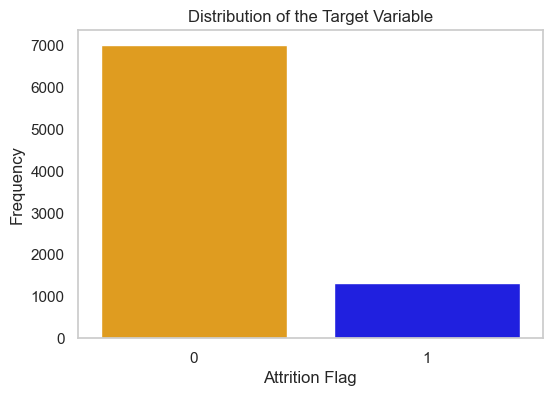

In [659]:
# Frequency distribution of the target variable
plt.figure(figsize=(6, 4))
sns.countplot(data=data_cleaned, x='Attrition_Flag', palette=['orange', 'blue'])  # Specify orange and blue colors
plt.title('Distribution of the Target Variable')
plt.xlabel('Attrition Flag')
plt.ylabel('Frequency')
plt.grid(False)
plt.show()

**Scatterplots**

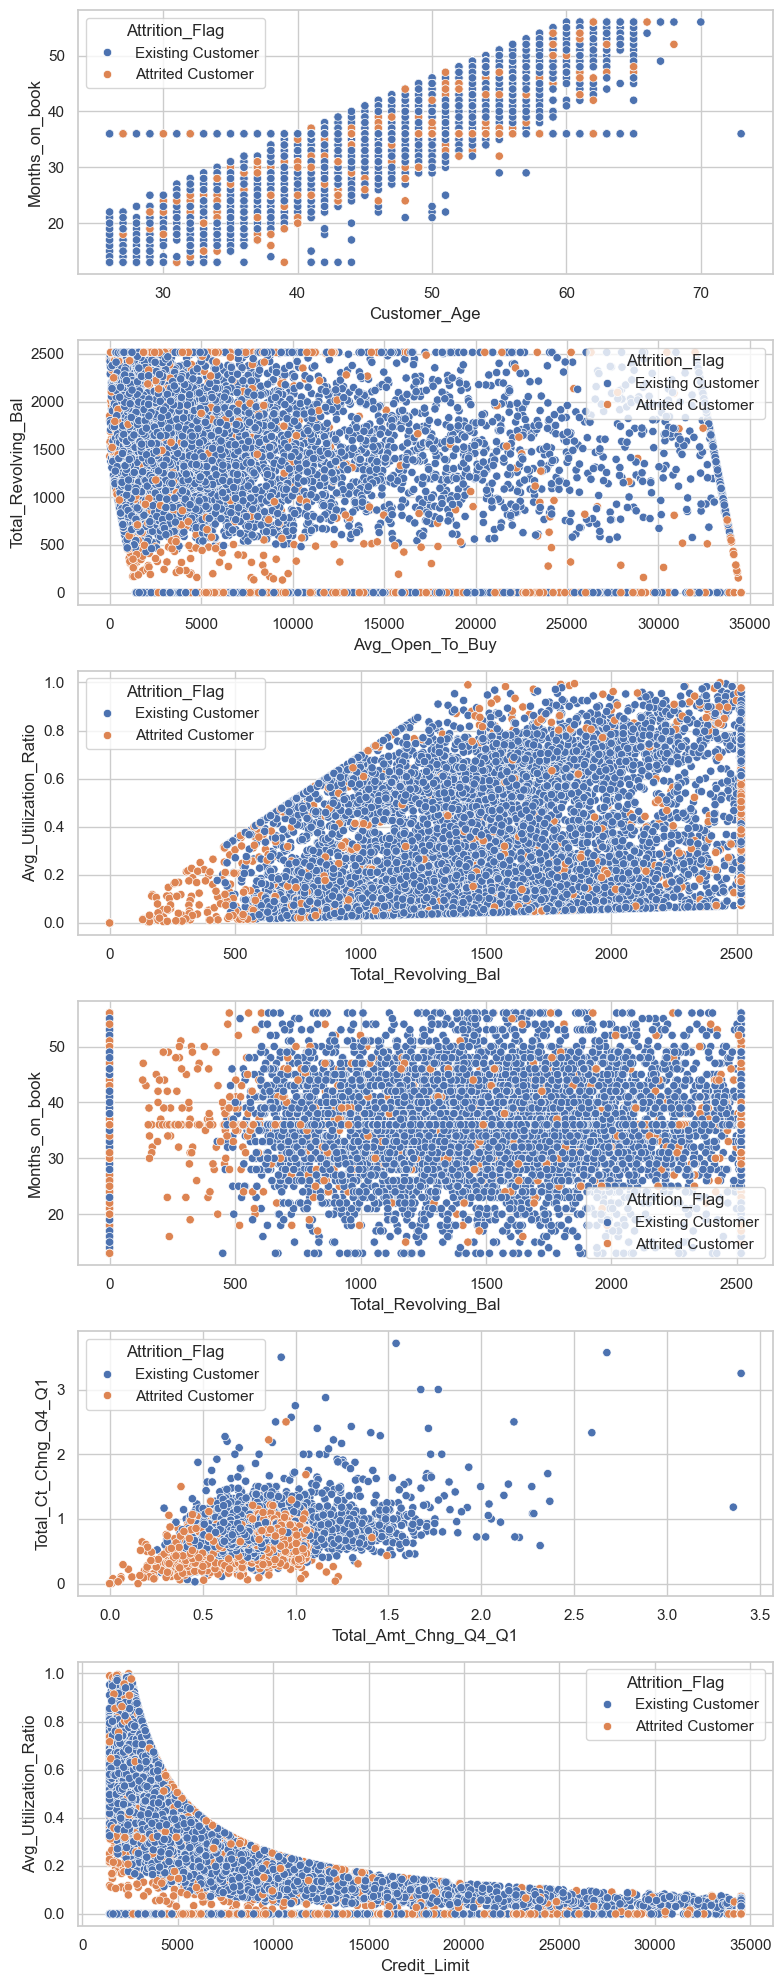

In [662]:
fig, axes = plt.subplots(6, 1, figsize=(8, 20)) 

sns.scatterplot(data=data, x='Customer_Age', y='Months_on_book', hue='Attrition_Flag', ax=axes[0])
sns.scatterplot(data=data, x='Avg_Open_To_Buy', y='Total_Revolving_Bal', hue='Attrition_Flag', ax=axes[1])
sns.scatterplot(data=data, x='Total_Revolving_Bal', y='Avg_Utilization_Ratio', hue='Attrition_Flag', ax=axes[2])
sns.scatterplot(data=data, x='Total_Revolving_Bal', y='Months_on_book', hue='Attrition_Flag', ax=axes[3])
sns.scatterplot(data=data, x='Total_Amt_Chng_Q4_Q1', y='Total_Ct_Chng_Q4_Q1', hue='Attrition_Flag', ax=axes[4])
sns.scatterplot(data=data, x='Credit_Limit', y='Avg_Utilization_Ratio', hue='Attrition_Flag', ax=axes[5])

plt.tight_layout()
plt.show()

**Outlier Analysis**

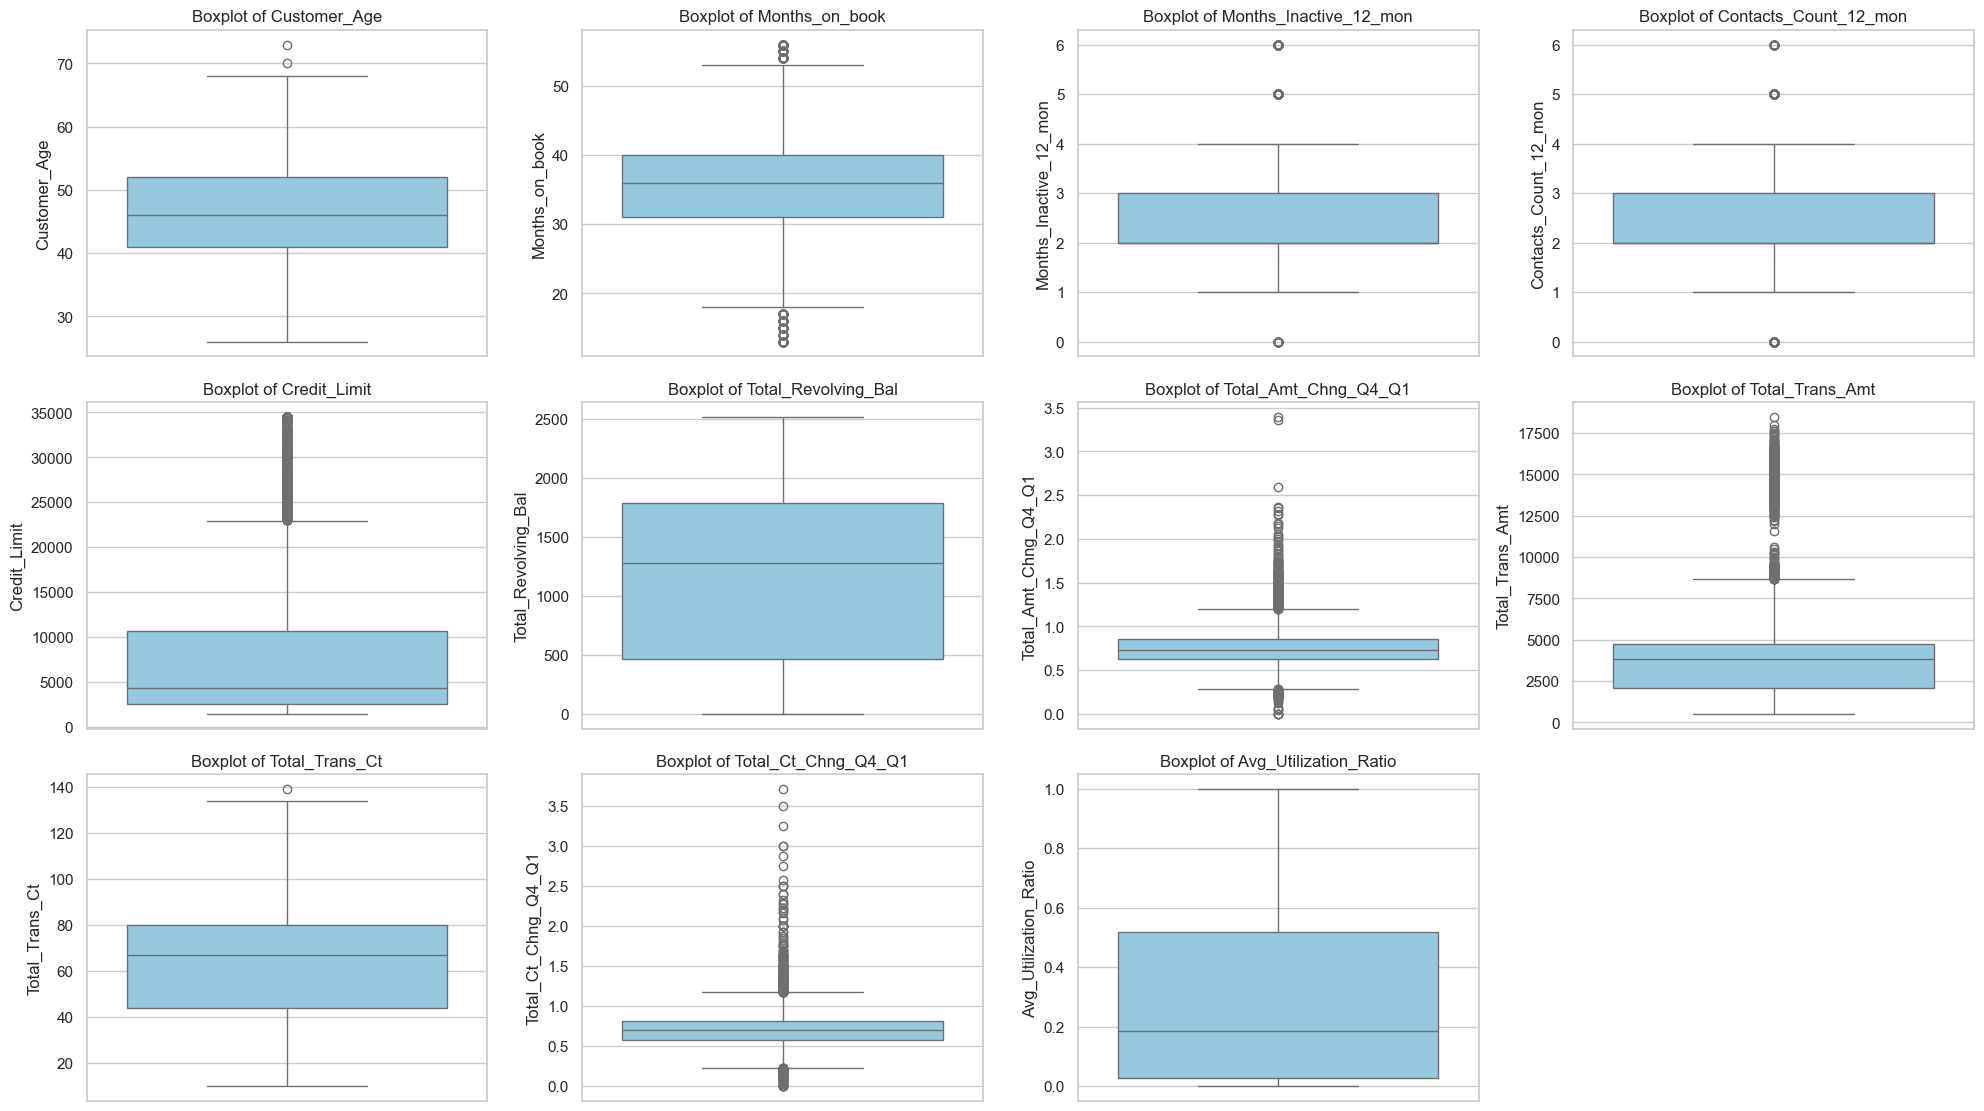

In [665]:
numeric_columns = [
    'Customer_Age', 'Months_on_book', 'Months_Inactive_12_mon', 
    'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 
    'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 
    'Avg_Utilization_Ratio'
]

# Plot boxplots for numeric columns
plt.figure(figsize=(20, 15))
for i, column in enumerate(numeric_columns, 1):
    plt.subplot(4, 4, i)
    sns.boxplot(y=data_cleaned[column], color='skyblue')
    plt.title(f'Boxplot of {column}')
plt.tight_layout()
plt.show()

The boxplots show that while most customers fall into a standard range for these features, some have outliers. This suggests diverse customer profiles.

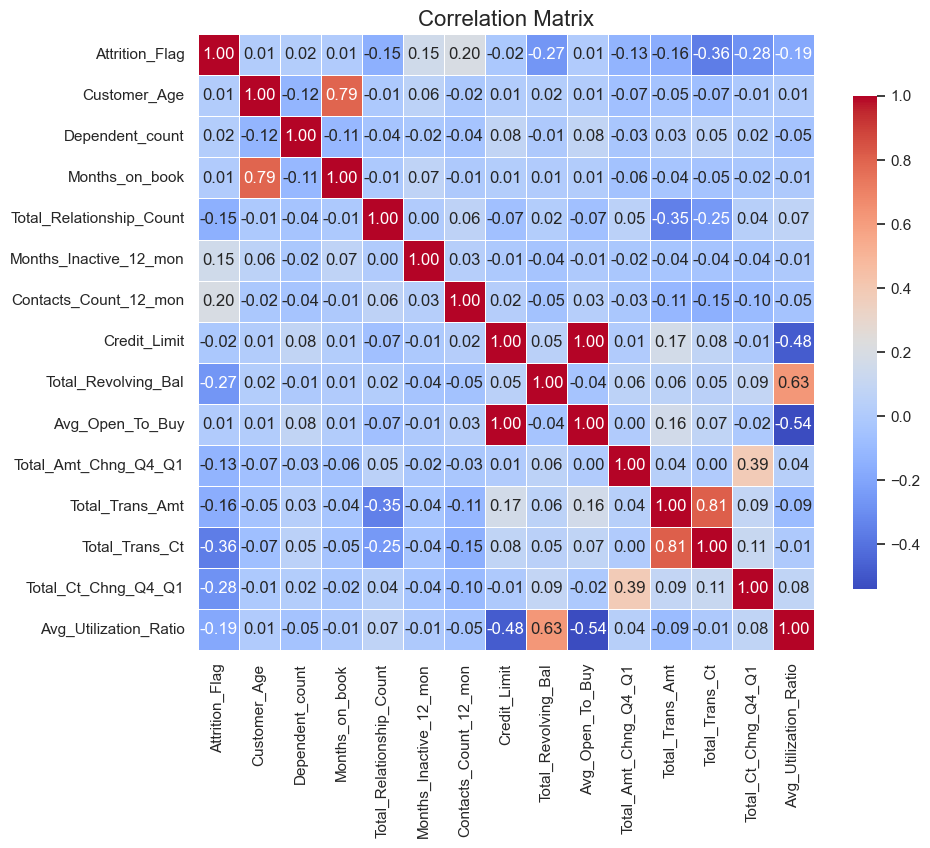

In [667]:
# Variables for correlation analysis
data_corr = data_cleaned[[
    "Attrition_Flag", "Customer_Age", "Dependent_count", "Months_on_book", "Total_Relationship_Count",
    "Months_Inactive_12_mon", "Contacts_Count_12_mon", "Credit_Limit", "Total_Revolving_Bal",
    "Avg_Open_To_Buy", "Total_Amt_Chng_Q4_Q1", "Total_Trans_Amt", "Total_Trans_Ct",
    "Total_Ct_Chng_Q4_Q1", "Avg_Utilization_Ratio"
]]

# Plot the correlation matrix
correlation_matrix = data_corr.corr()
plt.figure(figsize=(10, 8))  # Adjusted figure size for better readability
sns.heatmap(
    correlation_matrix, 
    annot=True, 
    cmap='coolwarm', 
    fmt=".2f", 
    linewidths=0.5, 
    square=True, 
    cbar_kws={"shrink": 0.8}  # Adjust color bar size
)
plt.title('Correlation Matrix', fontsize=16)
plt.show()

## Analysis:

Correlation Summary:

**High Correlation:**

Customer_Age and Months_on_book.

Credit_Limit and Avg_Open_To_Buy (perfect positive correlation)

Total_Revolving_Bal and Avg_Utilization_Ratio .

**Moderate Correlations:**

Total_Trans_Ct and Total_Trans_Amt 

Credit_Limit and Avg_Utilization_Ratio

Gender and Credit_Limit

**Low Correlations:**
Dependent_count

## Feature Selection
Lets Remove the Column Avg_Open_to_Buy since its highly correlated with Credit Limit. This will ensure better analysis
We will also remove Dependent_count since it has a very low correlation with our target variable


In [672]:
# Drop the columns Avg_Open_To_Buy and Dependent_count
data_cleaned = data_cleaned.drop(columns=['Avg_Open_To_Buy', 'Dependent_count'])

# Display the updated DataFrame
data_cleaned.head()


,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,768805383,0,45,M,High School,Married,60 - 80,Blue,39,5,1,3,12691.0,777,1.335,1144,42,1.625,0.061
1,818770008,0,49,F,Graduate,Single,Less than 40,Blue,44,6,1,2,8256.0,864,1.541,1291,33,3.714,0.105
2,713982108,0,51,M,Graduate,Married,80 - 120,Blue,36,4,1,0,3418.0,0,2.594,1887,20,2.333,0.000
4,709106358,0,40,M,Uneducated,Married,60 - 80,Blue,21,5,1,0,4716.0,0,2.175,816,28,2.500,0.000
5,713061558,0,44,M,Graduate,Married,40 - 60,Blue,36,3,1,2,4010.0,1247,1.376,1088,24,0.846,0.311


## Data Preparation (More Feature Engineering)
Lets Transform categorical data into numeric so that we can perform analysis

In [675]:
# Importing library
from sklearn.preprocessing import LabelEncoder

# Creating the Label encoder
Label_pre = LabelEncoder()

# Data type transformation: Selecting non-numeric columns
data_cols = data_cleaned.select_dtypes(exclude=['int', 'float']).columns
label_col = list(data_cols)

# Applying encoder and saving back to the DataFrame
for col in label_col:
    data_cleaned[col] = Label_pre.fit_transform(data_cleaned[col])

# Viewing the updated DataFrame
data_cleaned.head()


,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,768805383,0,45,1,3,1,2,0,39,5,1,3,12691.0,777,1.335,1144,42,1.625,0.061
1,818770008,0,49,0,2,2,4,0,44,6,1,2,8256.0,864,1.541,1291,33,3.714,0.105
2,713982108,0,51,1,2,1,3,0,36,4,1,0,3418.0,0,2.594,1887,20,2.333,0.000
4,709106358,0,40,1,5,1,2,0,21,5,1,0,4716.0,0,2.175,816,28,2.500,0.000
5,713061558,0,44,1,2,1,1,0,36,3,1,2,4010.0,1247,1.376,1088,24,0.846,0.311


## Model Training and Data Splitting
We split our dataset into training and testing subsets

In [678]:
# Split the data into features (X) and target (y)
X = data_cleaned.drop("Attrition_Flag", axis=1)  # Drop the target column to get the features
y = data_cleaned["Attrition_Flag"]  # Set the target column


In [680]:
X.shape


(8348, 18)

In [682]:
y.shape


(8348,)

In [684]:
# Splitting the dataset
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling the data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



In [686]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [688]:
X_train.shape

(6678, 18)

In [690]:
y_train.shape

(6678,)

## Machine learning Modelling

In [693]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import GridSearchCV

# Dictionary of models with hyperparameters to reduce overfitting
models = {
    # Logistic Regression with regularization
    "Logistic Regression": LogisticRegression(C=0.01, max_iter=1000),

    # Naive Bayes (less prone to overfitting)
    "Naive Bayes": GaussianNB(),

    # Random Forest with restricted depth and estimators
    "Random Forest": 
RandomForestClassifier(
    n_estimators=100,         # Fewer trees
    max_depth=10,             # Limit depth of trees
    min_samples_split=10,     # Minimum samples to split an internal node
    min_samples_leaf=5,       # Minimum samples in a leaf node
    max_features='sqrt',      # Consider a subset of features at each split
    random_state=42
),
    "AdaBoost": AdaBoostClassifier(),

    # LightGBM model
    "LightGBM": LGBMClassifier(),
   }

# Model training and evaluation with tqdm
from tqdm import tqdm

for name, model in tqdm(models.items(), desc="Training models", total=len(models)):
    # Train model
    model.fit(X_train, y_train)

    # Evaluate on test data
    score = model.score(X_test, y_test)
    
    # Predict on test data
    model_pred = model.predict(X_test)

    # Display results
    print(f"\n{name}: Accuracy = {score:.2%}")


Training models:  20%|██        | 1/5 [00:00<00:00,  7.46it/s]


Logistic Regression: Accuracy = 82.81%

Naive Bayes: Accuracy = 82.81%


Training models:  60%|██████    | 3/5 [00:01<00:01,  1.61it/s]


Random Forest: Accuracy = 93.83%


Training models:  80%|████████  | 4/5 [00:02<00:00,  1.47it/s]


AdaBoost: Accuracy = 95.51%
[LightGBM] [Info] Number of positive: 1041, number of negative: 5637
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000861 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2036
[LightGBM] [Info] Number of data points in the train set: 6678, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.155885 -> initscore=-1.689170
[LightGBM] [Info] Start training from score -1.689170


Training models: 100%|██████████| 5/5 [00:02<00:00,  1.78it/s]


LightGBM: Accuracy = 97.19%


## Evaluation Metrics
**Cross Validation**
Lets make sure that the 97% accuracy acheived by LGM is not misleading. We will perform a cross validation test to ensure this.


In [696]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import cross_val_score

# Initialize the model
model = LGBMClassifier()

# Perform 5-fold cross-validation
cv_scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')

# Print the mean accuracy and standard deviation
print("Cross-validation accuracy: {:.2f} ± {:.2f}".format(cv_scores.mean(), cv_scores.std()))


[LightGBM] [Info] Number of positive: 1062, number of negative: 5616
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000826 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2026
[LightGBM] [Info] Number of data points in the train set: 6678, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.159030 -> initscore=-1.665466
[LightGBM] [Info] Start training from score -1.665466
[LightGBM] [Info] Number of positive: 1062, number of negative: 5616
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000994 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2038
[LightGBM] [Info] Number of data points in the train set: 6678, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.159030 -> initscore=-1.665466
[LightGBM] [Info] Start training from score -1.665466
[LightGBM] [Info] 

The dataset (cleaned) has a sufficient number of rows (approx. 7500), so 5-fold cross-validation is appropriate. 
The variation in accuracy between the folds is small (4%), indicating consistent performance

**Probabilities**

Now, Lets explore some probabilities. Probabilities help explain how confident the model is in its decision

In [701]:
for name, model in models.items():
    yhat = model.predict(X)
    print(f"{name} - Prediction for the first data point: {yhat[0]}")
    
    if hasattr(model, "predict_proba"):
        yhat_proba = model.predict_proba(X)
        print(f"{name} - Prediction probabilities for the first data point: {yhat_proba[0]}")



Logistic Regression - Prediction for the first data point: 0
Logistic Regression - Prediction probabilities for the first data point: [0.70613165 0.29386835]
Naive Bayes - Prediction for the first data point: 0
Naive Bayes - Prediction probabilities for the first data point: [0.78363891 0.21636109]
Random Forest - Prediction for the first data point: 0
Random Forest - Prediction probabilities for the first data point: [0.96909151 0.03090849]
AdaBoost - Prediction for the first data point: 0
AdaBoost - Prediction probabilities for the first data point: [0.54965796 0.45034204]
LightGBM - Prediction for the first data point: 0
LightGBM - Prediction probabilities for the first data point: [9.99418501e-01 5.81499394e-04]


This suggests LightGBM and Random Forest are the most confident
## Classification Report


Model: Logistic Regression
Accuracy: 82.81%

Classification Report:
               precision    recall  f1-score   support

           0       0.83      1.00      0.91      1383
           1       0.00      0.00      0.00       287

    accuracy                           0.83      1670
   macro avg       0.41      0.50      0.45      1670
weighted avg       0.69      0.83      0.75      1670



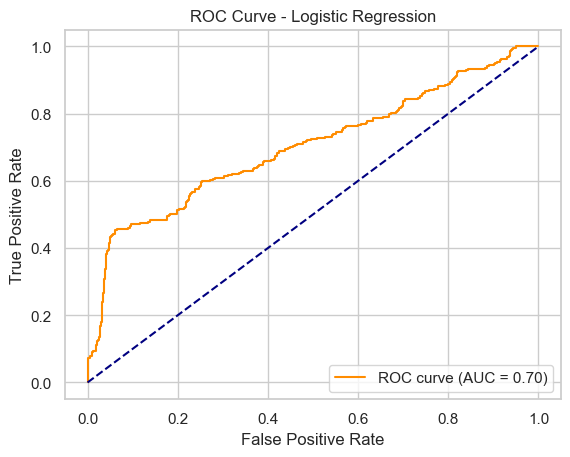

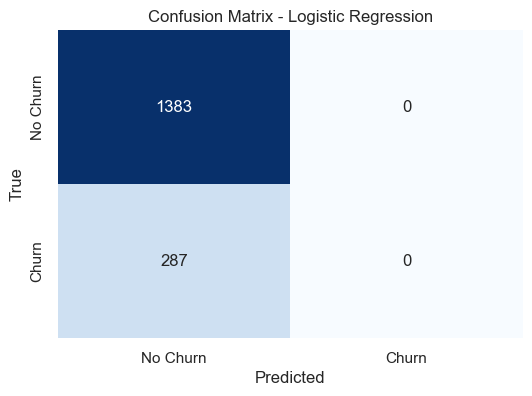

Confusion Matrix Details:
TP: 1383, TN: 0, FP: 0, FN: 287

Model: Naive Bayes
Accuracy: 82.81%

Classification Report:
               precision    recall  f1-score   support

           0       0.83      1.00      0.91      1383
           1       0.00      0.00      0.00       287

    accuracy                           0.83      1670
   macro avg       0.41      0.50      0.45      1670
weighted avg       0.69      0.83      0.75      1670



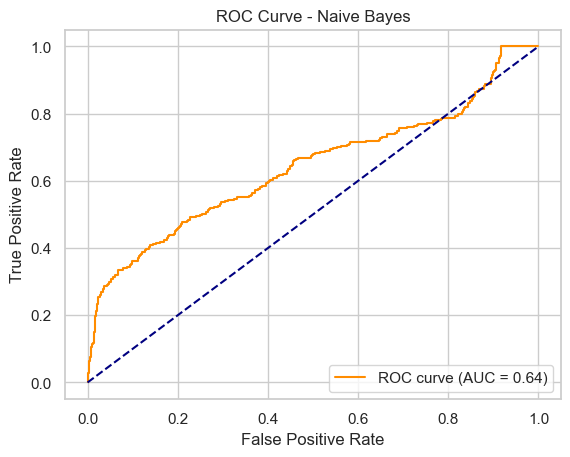

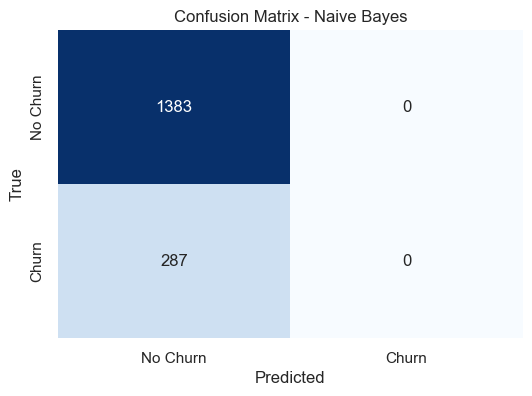

Confusion Matrix Details:
TP: 1383, TN: 0, FP: 0, FN: 287

Model: Random Forest
Accuracy: 93.83%

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.98      0.96      1383
           1       0.88      0.74      0.80       287

    accuracy                           0.94      1670
   macro avg       0.92      0.86      0.88      1670
weighted avg       0.94      0.94      0.94      1670



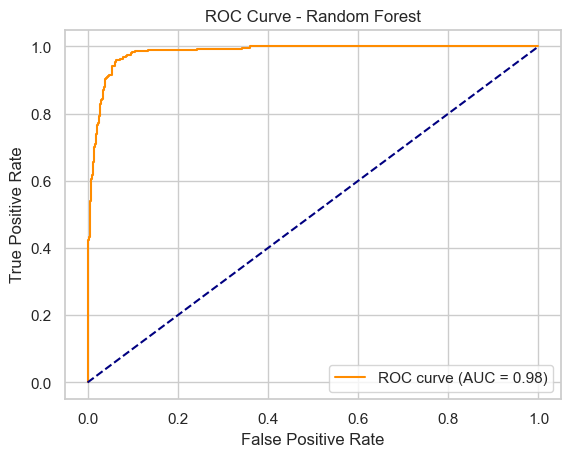

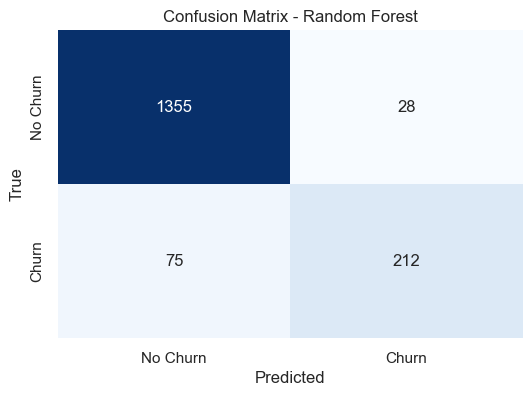

Confusion Matrix Details:
TP: 1355, TN: 212, FP: 28, FN: 75

Model: AdaBoost
Accuracy: 95.51%

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.98      0.97      1383
           1       0.90      0.84      0.86       287

    accuracy                           0.96      1670
   macro avg       0.93      0.91      0.92      1670
weighted avg       0.95      0.96      0.95      1670



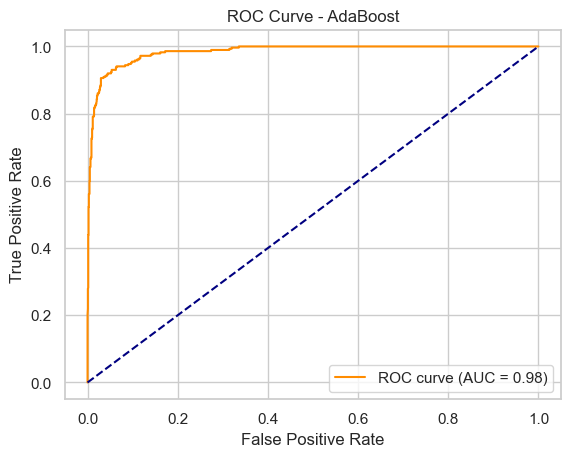

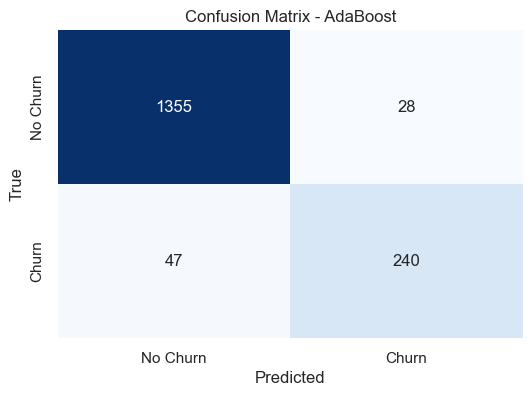

Confusion Matrix Details:
TP: 1355, TN: 240, FP: 28, FN: 47

Model: LightGBM
[LightGBM] [Info] Number of positive: 1041, number of negative: 5637
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000799 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2036
[LightGBM] [Info] Number of data points in the train set: 6678, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.155885 -> initscore=-1.689170
[LightGBM] [Info] Start training from score -1.689170
Accuracy: 97.19%

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98      1383
           1       0.93      0.91      0.92       287

    accuracy                           0.97      1670
   macro avg       0.95      0.95      0.95      1670
weighted avg       0.97      0.97      0.97      1670



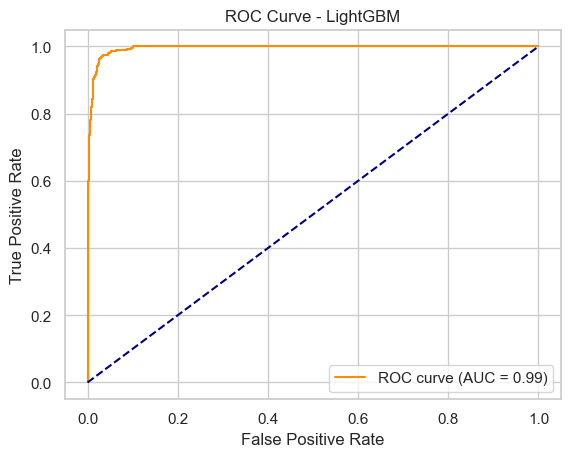

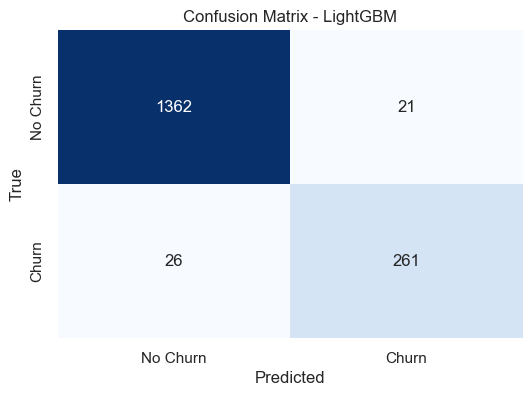

Confusion Matrix Details:
TP: 1362, TN: 261, FP: 21, FN: 26


In [703]:
# Required imports
from sklearn.metrics import (
    accuracy_score, 
    classification_report, 
    roc_curve, 
    auc, 
    confusion_matrix
)

# Iterating over each model
for name, model in models.items():
    print(f"\nModel: {name}")

    # Training the model
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]  # Probability predictions for ROC

    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {acc:.2%}")

    # Classification Report
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.figure()
    plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})', color='darkorange')
    plt.plot([0, 1], [0, 1], linestyle='--', color='navy')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {name}')
    plt.legend(loc="lower right")
    plt.show()

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.xticks(ticks=[0.5, 1.5], labels=['No Churn', 'Churn'])
    plt.yticks(ticks=[0.5, 1.5], labels=['No Churn', 'Churn'])
    plt.show()

    # Confusion Matrix Details
    tp, fn = cm[0, 0], cm[1, 0]  # True Positives, False Negatives
    fp, tn = cm[0, 1], cm[1, 1]  # False Positives, True Negatives
    print(f"Confusion Matrix Details:")
    print(f"TP: {tp}, TN: {tn}, FP: {fp}, FN: {fn}")

**Is the AUC indicating an overfit?**

LightGBM: AUC = 0.99 is likely justified given the combination of high accuracy, precision, recall, and F1-score.

Random Forest and ADABoost: AUC = 0.99 may also be valid, though its slightly lower metrics compared to LightGBM warrant further checks for overfitting or imbalanced performance but since LGM outperforms other models, I will go ahead with it

In [706]:
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

# Initialize dictionary to store results
results = []

# Evaluate each model
for name, model in models.items():
    # Train the model
    model.fit(X_train, y_train)

    # Predict on test set
    y_pred = model.predict(X_test)

    # Accuracy
    acc = accuracy_score(y_test, y_pred)

    # Extract other metrics from classification report
    report = classification_report(y_test, y_pred, output_dict=True)
    precision = report['weighted avg']['precision']
    recall = report['weighted avg']['recall']
    f1 = report['weighted avg']['f1-score']

    # Append results for this model
    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })

# Convert results to a DataFrame and sort by accuracy
df_metrics = pd.DataFrame(results).sort_values(by='Accuracy', ascending=False)

# Display sorted results
df_metrics


[LightGBM] [Info] Number of positive: 1041, number of negative: 5637
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000871 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2036
[LightGBM] [Info] Number of data points in the train set: 6678, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.155885 -> initscore=-1.689170
[LightGBM] [Info] Start training from score -1.689170


,Model,Accuracy,Precision,Recall,F1-Score
4,LightGBM,0.971856,0.971689,0.971856,0.971758
3,AdaBoost,0.955090,0.954283,0.955090,0.954474
2,Random Forest,0.938323,0.936516,0.938323,0.936088
0,Logistic Regression,0.828144,0.685822,0.828144,0.750293
1,Naive Bayes,0.828144,0.685822,0.828144,0.750293


## Recommendation
LightGBM is the best model based on all the important metrics like accuracy, precision, recall, and F1-score. It is highly accurate, good at correctly identifying positive cases, and makes very few mistakes with false positives. Its high recall shows it captures most of the actual positive cases, and its strong F1-score makes it a good choice, even if the dataset is unbalanced. Overall, LightGBM is a reliable and effective option.

In [717]:
from IPython.display import Image, display

# URL of the PNG
url = "https://contenthub-static.grammarly.com/blog/wp-content/uploads/2019/02/bmd-4584.png"
display(Image(url=url, width=600)) 

**Thankyou for your time!**

ChatGPT Prompts

In [729]:
#ChatGPT Prompts

#1.Give code to transform a column, Income_Category which has a value 'Less than 40' to 0-40
#My dataset is named data_cleaned

#2. NameError: name 'X_train' (with Image uploaded) please debug

#3.There is a column names Income_Category in thid dataset has "K" in it remove that. and Also it has like a value Less than '$40K' transform it into numeric 0-40
#Basically give code for transforming the column for analysis. Give two codes First for removing K and $ . (I also uploaded dataset)


In [599]:
#"Response 1: 
#Transform the 'Income_Category' column to replace 'Less than 40' with '0-40'
#data_cleaned['Income_Category'] = data_cleaned['Income_Category'].replace('Less than 40', '0-40')
#Check unique values to verify the transformation
#print(data_cleaned['Income_Category'].unique())"

#Response 2:
#Splitting the dataset
#from sklearn.model_selection import train_test_split

#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42 data
#from sklearn.preprocessing import StandardScaler

#scaler = StandardScaler()
#X_train_scaled = scaler.fit_transform(X_train)
#X_test_scaled = scaler

#Response3:
# Remove 'K' and '$' signs
#data_cleaned['Income_Category'] = data_cleaned['Income_Category'].str.replace('K', '', regex=False)
#data_cleaned['Income_Category'] = data_cleaned['Income_Category'].str.replace('$', '', regex=False)

# Check the column after transformation
#print(data_cleaned['Income_Category'].unique())
